In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = {
"Order_ID": ["ORD001","ORD002","ORD003","ORD004","ORD005","ORD006","ORD007","ORD008","ORD009","ORD010",
"ORD011","ORD012","ORD013","ORD014","ORD015","ORD016","ORD017","ORD018","ORD019","ORD020"],
"Product_Category": ["Electronics","Clothing","Groceries","Electronics","Furniture",
"Clothing","Electronics","Groceries","Furniture","Clothing",
"Electronics","Furniture","Groceries","Clothing","Electronics",
"Furniture","Groceries","Electronics","Clothing","Furniture"],
"Customer_Age": [25,32,28,41,35,24,29,45,38,27,31,42,26,36,30,48,33,29,40,37],
"Quantity": [2,4,6,1,3,5,2,8,2,4,3,1,7,5,2,2,9,3,4,2],
"Unit_Price": [500,800,120,1500,2200,650,1800,100,2500,750,1200,3000,150,900,2000,2800,130,1600,850,2400],
"Discount": [5,10,0,15,8,5,10,0,12,5,8,15,0,10,5,12,10,0,8,5],
"Delivery_Days": [3,5,2,4,7,3,4,2,8,5,3,6,2,4,3,7,2,4,5,6],
"Sales": [950,2880,720,1275,6072,3087,3240,800,4400,2850,
3312,2550,1050,4050,3520,5040,1170,4416,3230,4560]
}

# Q1. Convert dictionary to DataFrame
df = pd.DataFrame(data)
df

,Order_ID,Product_Category,Customer_Age,Quantity,Unit_Price,Discount,Delivery_Days,Sales
0,ORD001,Electronics,25,2,500,5,3,950
1,ORD002,Clothing,32,4,800,10,5,2880
2,ORD003,Groceries,28,6,120,0,2,720
3,ORD004,Electronics,41,1,1500,15,4,1275
4,ORD005,Furniture,35,3,2200,8,7,6072
5,ORD006,Clothing,24,5,650,5,3,3087
6,ORD007,Electronics,29,2,1800,10,4,3240
7,ORD008,Groceries,45,8,100,0,2,800
8,ORD009,Furniture,38,2,2500,12,8,4400
9,ORD010,Clothing,27,4,750,5,5,2850


In [ ]:
df.head()

,Order_ID,Product_Category,Customer_Age,Quantity,Unit_Price,Discount,Delivery_Days,Sales
0,ORD001,Electronics,25,2,500,5,3,950
1,ORD002,Clothing,32,4,800,10,5,2880
2,ORD003,Groceries,28,6,120,0,2,720
3,ORD004,Electronics,41,1,1500,15,4,1275
4,ORD005,Furniture,35,3,2200,8,7,6072


In [ ]:
df.tail()

,Order_ID,Product_Category,Customer_Age,Quantity,Unit_Price,Discount,Delivery_Days,Sales
15,ORD016,Furniture,48,2,2800,12,7,5040
16,ORD017,Groceries,33,9,130,10,2,1170
17,ORD018,Electronics,29,3,1600,0,4,4416
18,ORD019,Clothing,40,4,850,8,5,3230
19,ORD020,Furniture,37,2,2400,5,6,4560


In [ ]:
print(df.shape)

(20, 8)


In [ ]:
df.dtypes

Order_ID              str
Product_Category      str
Customer_Age        int64
Quantity            int64
Unit_Price          int64
Discount            int64
Delivery_Days       int64
Sales               int64
dtype: object

In [ ]:
df.isnull().sum()

Order_ID            0
Product_Category    0
Customer_Age        0
Quantity            0
Unit_Price          0
Discount            0
Delivery_Days       0
Sales               0
dtype: int64

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
# Q9. Handle missing values (fill numeric with median, categorical with mode)
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df = df.drop_duplicates()
print(df.shape)

(20, 8)


In [ ]:
print(df.isnull().sum().sum(), df.duplicated().sum())

0 0


In [ ]:
print(df['Sales'].mean())

2958.6


In [ ]:
print(df['Sales'].median())

3158.5


In [ ]:
print(df['Sales'].min(), df['Sales'].max())

720 6072


In [ ]:
print(df['Sales'].std())

1558.6566213114081


In [ ]:
print(df['Quantity'].mean())

3.75


In [ ]:
print(df['Delivery_Days'].mean())

4.25


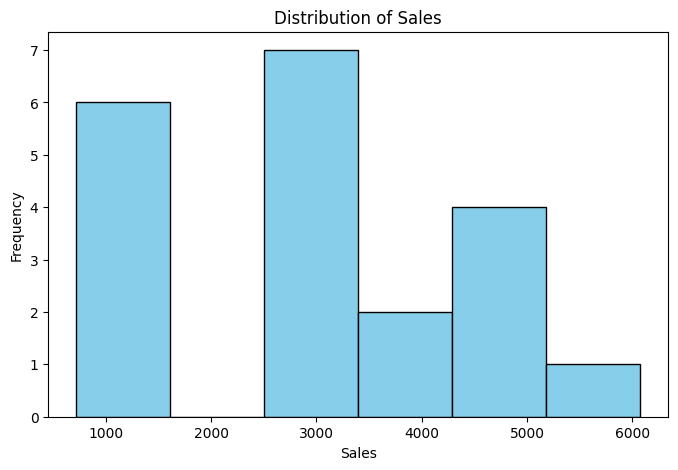

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=6, color='skyblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

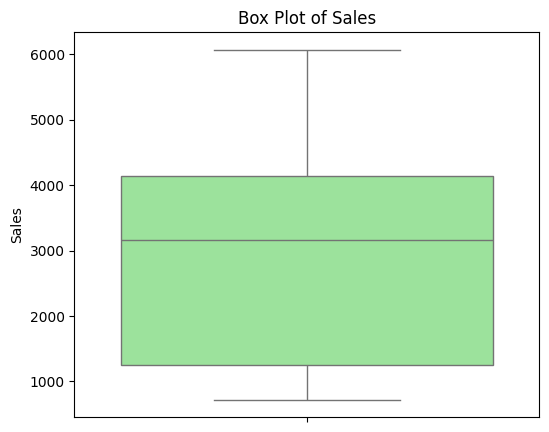

Empty DataFrame
Columns: [Order_ID, Sales]
Index: []


In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df['Sales'], color='lightgreen')
plt.title('Box Plot of Sales')
plt.show()

Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['Sales'] < lower) | (df['Sales'] > upper)]
print(outliers[['Order_ID','Sales']])

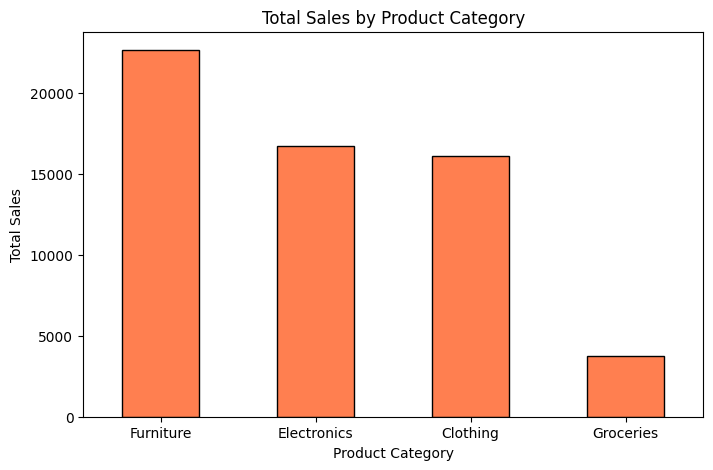

Product_Category
Furniture      22622
Electronics    16713
Clothing       16097
Groceries       3740
Name: Sales, dtype: int64


In [ ]:
category_sales = df.groupby('Product_Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()
print(category_sales)

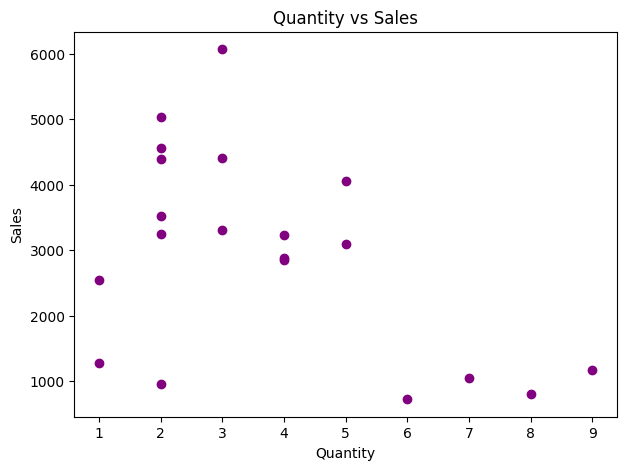

-0.48817123501926973


In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['Quantity'], df['Sales'], color='purple')
plt.title('Quantity vs Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.show()
print(df['Quantity'].corr(df['Sales']))

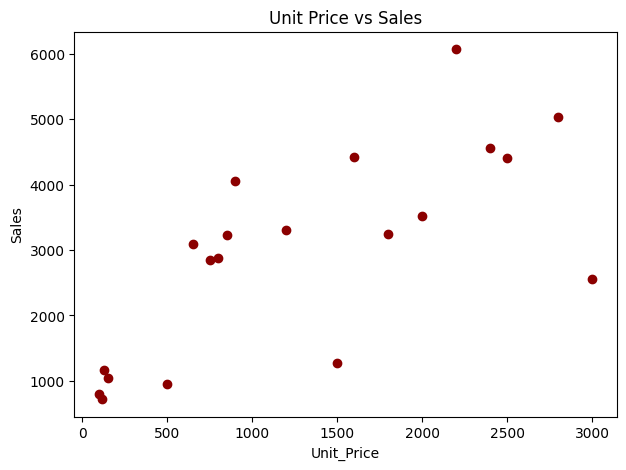

0.7108903588920658


In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['Unit_Price'], df['Sales'], color='darkred')
plt.title('Unit Price vs Sales')
plt.xlabel('Unit_Price')
plt.ylabel('Sales')
plt.show()
print(df['Unit_Price'].corr(df['Sales']))

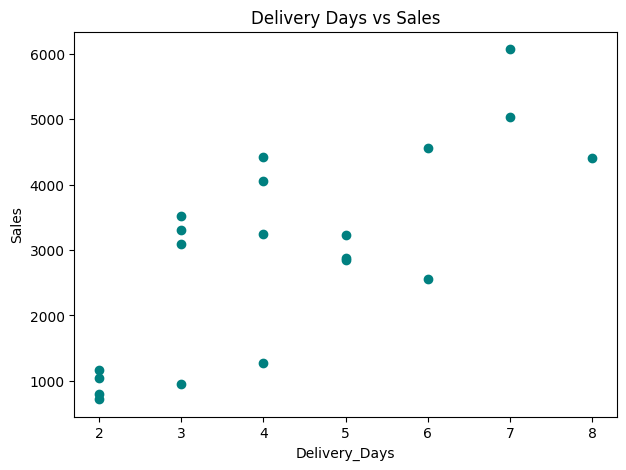

0.7553374526187799


In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['Delivery_Days'], df['Sales'], color='teal')
plt.title('Delivery Days vs Sales')
plt.xlabel('Delivery_Days')
plt.ylabel('Sales')
plt.show()
print(df['Delivery_Days'].corr(df['Sales']))

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = df[['Customer_Age','Quantity','Unit_Price','Discount','Delivery_Days']]  # Q29 features
y = df['Sales']  # Q30 target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)  # Q31 train

y_pred = model.predict(X_test)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.6528132774992619
MAE: 842.3949000436439


In [ ]:
new_order = pd.DataFrame({
    'Customer_Age': [29],
    'Quantity': [3],
    'Unit_Price': [1000],
    'Discount': [10],
    'Delivery_Days': [4]
})
new_order

,Customer_Age,Quantity,Unit_Price,Discount,Delivery_Days
0,29,3,1000,10,4


In [ ]:
predicted_sales = model.predict(new_order)
print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 2790.6663729500947
